# Research Question 2 – Relative Price Dynamics of Butter and Margarine

**Question:**  
How do the relative price dynamics between butter and margarine evolve during periods of elevated food inflation?

This notebook is written in a presentation-friendly structure so that every step is easy to explain to the supervisor:
1. Imports
2. Configuration
3. Helper functions for loading and cleaning data
4. Merge and feature engineering
5. Inflation phase classification
6. Relative-price analysis
7. At least four different chart types

## Important note
I do **not** need APIs if you already have the local files.

This notebook is designed to use:
- `eurostat_butter_cpi.json`
- `eurostat_margarine_hicp.json` or `eurostat_margarine_cpi.json`

### Fallback
At the moment, only a butter file and a broader dairy CPI file are available locally.  
Therefore, this notebook contains a **fallback mode**:
- if a margarine file is found, it uses margarine directly,
- otherwise it temporarily uses `eurostat_cpi_dairy.json` as a **proxy** for testing the workflow.

For the final analysis, the margarine series should replace the fallback proxy.


In [21]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. Configuration

Here we define file paths, analysis period, and the inflation threshold.


In [22]:
BASE_DIR = Path(".")

# Main expected files.
BUTTER_FILE = BASE_DIR / "eurostat_butter_cpi.json"
MARGARINE_FILE_CANDIDATES = [
    BASE_DIR / "eurostat_margarine_hicp.json",
    BASE_DIR / "eurostat_margarine_cpi.json",
    BASE_DIR / "margarine_hicp.json",
    BASE_DIR / "margarine_cpi.json",
]

# Fallback file that is currently available locally.
FALLBACK_PROXY_FILE = BASE_DIR / "eurostat_cpi_dairy.json"

ANALYSIS_START = pd.Timestamp("2019-01-01")
ANALYSIS_END = pd.Timestamp("2025-12-31")

# Food inflation is treated as elevated when butter YoY inflation exceeds this threshold.
ELEVATED_INFLATION_THRESHOLD = 5.0


## 2. Helper function: Read Eurostat / HICP / CPI JSON

This converts the nested Eurostat-like structure into a clean monthly DataFrame.


In [23]:
def eurostat_json_to_df(file_path: Path, value_name: str) -> pd.DataFrame:
    """
    Read a Eurostat-style JSON file and convert it into a monthly DataFrame.

    Parameters
    ----------
    file_path : Path
        Path to the local JSON file.
    value_name : str
        Name of the numeric value column.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - datum
        - <value_name>
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    values = data["value"]

    rows = []

    for label_key, position in time_index.items():
        position_str = str(position)

        # Only keep observations that contain actual values.
        if position_str in values:
            rows.append(
                {
                    "datum_raw": time_labels[label_key],
                    value_name: values[position_str],
                }
            )

    df = pd.DataFrame(rows)

    # The uploaded files use labels such as "2020-01".
    # This parsing also works for that monthly format.
    df["datum"] = pd.to_datetime(df["datum_raw"], errors="coerce")

    df.drop(columns=["datum_raw"], inplace=True)

    # Convert values to numeric and turn invalid strings into NaN.
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    return df


## 3. Helper functions: file selection and data cleaning

These functions help us detect whether a margarine series is available and clean each time series consistently.


In [24]:
def find_first_existing_file(file_candidates: list[Path]) -> Path | None:
    """
    Return the first existing file from a list of candidates.
    """
    for candidate in file_candidates:
        if candidate.exists():
            return candidate
    return None


def clean_time_series(
    df: pd.DataFrame,
    value_column: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> pd.DataFrame:
    """
    Clean a monthly time series.

    Cleaning steps
    --------------
    - remove missing dates,
    - remove missing numeric values,
    - remove duplicate months,
    - sort chronologically,
    - restrict to the analysis window.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame.
    """
    cleaned_df = df.copy()

    cleaned_df = cleaned_df.dropna(subset=["datum", value_column])
    cleaned_df = cleaned_df.drop_duplicates(subset=["datum"], keep="last")
    cleaned_df = cleaned_df.sort_values("datum").reset_index(drop=True)

    cleaned_df = cleaned_df[
        (cleaned_df["datum"] >= start_date) & (cleaned_df["datum"] <= end_date)
    ].copy()

    return cleaned_df


def print_data_quality_report(df: pd.DataFrame) -> None:
    """
    Print a compact report for presentation and debugging.
    """
    print("=" * 72)
    print("DATA QUALITY REPORT")
    print("=" * 72)
    print(f"Rows: {len(df)}")
    print(f"Date range: {df['datum'].min().date()} to {df['datum'].max().date()}")
    print("\nMissing values per column:")
    print(df.isna().sum())
    print("\nDuplicate months:", int(df["datum"].duplicated().sum()))
    print("=" * 72)


## 4. Load the butter series and detect the comparison series

The notebook prefers a real margarine file.  
If no margarine file is found, it uses the broader dairy CPI file as a temporary proxy for testing the code structure.


In [25]:
butter_raw_df = eurostat_json_to_df(BUTTER_FILE, "butter_index")

margarine_file = find_first_existing_file(MARGARINE_FILE_CANDIDATES)

if margarine_file is not None:
    comparison_raw_df = eurostat_json_to_df(margarine_file, "margarine_index")
    comparison_label = "Margarine"
    comparison_column = "margarine_index"
    data_mode = "real_margarine_series"
elif FALLBACK_PROXY_FILE.exists():
    comparison_raw_df = eurostat_json_to_df(FALLBACK_PROXY_FILE, "margarine_proxy_index")
    comparison_label = "Fallback proxy: Milk, cheese and eggs"
    comparison_column = "margarine_proxy_index"
    data_mode = "fallback_proxy_series"
else:
    raise FileNotFoundError(
        "No margarine file and no fallback file were found. "
        "Please add a margarine JSON file or place eurostat_cpi_dairy.json in the project folder."
    )

print("Comparison series used:", comparison_label)
print("Mode:", data_mode)


Comparison series used: Margarine
Mode: real_margarine_series


## 5. Clean both series


In [26]:
butter_clean_df = clean_time_series(
    butter_raw_df,
    value_column="butter_index",
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

comparison_clean_df = clean_time_series(
    comparison_raw_df,
    value_column=comparison_column,
    start_date=ANALYSIS_START,
    end_date=ANALYSIS_END,
)

print("Butter shape:", butter_clean_df.shape)
print("Comparison shape:", comparison_clean_df.shape)

butter_clean_df.head()


Butter shape: (84, 2)
Comparison shape: (84, 2)


,butter_index,datum
49,167.2,2019-01-01
50,162.6,2019-02-01
51,157.6,2019-03-01
52,154.5,2019-04-01
53,153.8,2019-05-01


## 6. Merge the two series and create analysis features

This is the central transformation step for relative-price analysis.


In [27]:
def merge_and_engineer_features(
    butter_df: pd.DataFrame,
    other_df: pd.DataFrame,
    other_column: str,
) -> pd.DataFrame:
    """
    Merge both series and create features that describe relative price dynamics.
    """
    merged_df = pd.merge(butter_df, other_df, on="datum", how="inner")
    merged_df = merged_df.sort_values("datum").reset_index(drop=True)

    merged_df["butter_mom_pct"] = merged_df["butter_index"].pct_change() * 100
    merged_df["other_mom_pct"] = merged_df[other_column].pct_change() * 100

    merged_df["butter_yoy_pct"] = merged_df["butter_index"].pct_change(12) * 100
    merged_df["other_yoy_pct"] = merged_df[other_column].pct_change(12) * 100

    # Relative price ratio: values above 1 mean butter is more expensive relative to the comparison series.
    merged_df["relative_price_ratio"] = merged_df["butter_index"] / merged_df[other_column]

    # Relative spread in index points.
    merged_df["relative_price_gap"] = merged_df["butter_index"] - merged_df[other_column]

    # Difference in monthly price dynamics.
    merged_df["momentum_gap_mom"] = merged_df["butter_mom_pct"] - merged_df["other_mom_pct"]

    # Difference in yearly inflation.
    merged_df["inflation_gap_yoy"] = merged_df["butter_yoy_pct"] - merged_df["other_yoy_pct"]

    # Normalised versions make both series comparable on one scale.
    first_butter = merged_df["butter_index"].dropna().iloc[0]
    first_other = merged_df[other_column].dropna().iloc[0]

    merged_df["butter_norm"] = (merged_df["butter_index"] / first_butter) * 100
    merged_df["other_norm"] = (merged_df[other_column] / first_other) * 100

    # Phase classification based on butter inflation intensity.
    merged_df["inflation_phase"] = np.where(
        merged_df["butter_yoy_pct"] >= ELEVATED_INFLATION_THRESHOLD,
        "elevated_food_inflation",
        "normal_or_low_inflation",
    )

    return merged_df


In [28]:
analysis_df = merge_and_engineer_features(
    butter_clean_df,
    comparison_clean_df,
    other_column=comparison_column,
)

print_data_quality_report(analysis_df)

analysis_df.head()


DATA QUALITY REPORT
Rows: 84
Date range: 2019-01-01 to 2025-12-01

Missing values per column:
butter_index             0
datum                    0
margarine_index          0
butter_mom_pct           1
other_mom_pct            1
butter_yoy_pct          12
other_yoy_pct           12
relative_price_ratio     0
relative_price_gap       0
momentum_gap_mom         1
inflation_gap_yoy       12
butter_norm              0
other_norm               0
inflation_phase          0
dtype: int64

Duplicate months: 0


,butter_index,datum,margarine_index,butter_mom_pct,other_mom_pct,butter_yoy_pct,other_yoy_pct,relative_price_ratio,relative_price_gap,momentum_gap_mom,inflation_gap_yoy,butter_norm,other_norm,inflation_phase
0,167.2,2019-01-01,103.3,NaN,NaN,NaN,NaN,1.618587,63.9,NaN,NaN,100.000000,100.000000,normal_or_low_inflation
1,162.6,2019-02-01,105.5,-2.751196,2.129719,NaN,NaN,1.541232,57.1,-4.880915,NaN,97.248804,102.129719,normal_or_low_inflation
2,157.6,2019-03-01,106.1,-3.075031,0.568720,NaN,NaN,1.485391,51.5,-3.643751,NaN,94.258373,102.710552,normal_or_low_inflation
3,154.5,2019-04-01,106.2,-1.967005,0.094251,NaN,NaN,1.454802,48.3,-2.061256,NaN,92.404306,102.807357,normal_or_low_inflation
4,153.8,2019-05-01,109.3,-0.453074,2.919021,NaN,NaN,1.407136,44.5,-3.372095,NaN,91.985646,105.808325,normal_or_low_inflation


## 7. Build descriptive summaries

These summaries help explain how the butter–margarine relationship changes when food inflation is elevated.


In [29]:
def summarise_relative_dynamics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarise the relative price behaviour by inflation phase.
    """
    grouped_df = (
        df.groupby("inflation_phase", dropna=False)
        .agg(
            n_months=("datum", "count"),
            avg_butter_mom_pct=("butter_mom_pct", "mean"),
            avg_other_mom_pct=("other_mom_pct", "mean"),
            avg_butter_yoy_pct=("butter_yoy_pct", "mean"),
            avg_other_yoy_pct=("other_yoy_pct", "mean"),
            avg_relative_price_ratio=("relative_price_ratio", "mean"),
            avg_relative_price_gap=("relative_price_gap", "mean"),
            avg_momentum_gap_mom=("momentum_gap_mom", "mean"),
            avg_inflation_gap_yoy=("inflation_gap_yoy", "mean"),
            std_relative_price_ratio=("relative_price_ratio", "std"),
        )
        .reset_index()
    )

    return grouped_df


def print_interpretation(summary_df: pd.DataFrame) -> None:
    """
    Print a short interpretation for the supervisor presentation.
    """
    print("\n" + "=" * 72)
    print("INTERPRETATION OF RELATIVE PRICE DYNAMICS")
    print("=" * 72)

    elevated_row = summary_df.loc[
        summary_df["inflation_phase"] == "elevated_food_inflation"
    ]
    normal_row = summary_df.loc[
        summary_df["inflation_phase"] == "normal_or_low_inflation"
    ]

    if elevated_row.empty or normal_row.empty:
        print(
            "There are not enough observations in both inflation phases to compare them."
        )
        print("=" * 72)
        return

    elevated_row = elevated_row.iloc[0]
    normal_row = normal_row.iloc[0]

    print(
        f"Average relative price ratio during elevated inflation: "
        f"{elevated_row['avg_relative_price_ratio']:.3f}"
    )
    print(
        f"Average relative price ratio during normal/low inflation: "
        f"{normal_row['avg_relative_price_ratio']:.3f}"
    )
    print(
        f"Average yearly inflation gap during elevated inflation: "
        f"{elevated_row['avg_inflation_gap_yoy']:.2f} percentage points"
    )
    print(
        f"Average yearly inflation gap during normal/low inflation: "
        f"{normal_row['avg_inflation_gap_yoy']:.2f} percentage points"
    )

    if elevated_row["avg_relative_price_ratio"] > normal_row["avg_relative_price_ratio"]:
        print(
            "Pattern: Butter becomes relatively more expensive compared with the comparison series "
            "during periods of elevated food inflation."
        )
    else:
        print(
            "Pattern: Butter does not become relatively more expensive during elevated food inflation."
        )

    if abs(elevated_row["avg_momentum_gap_mom"]) > abs(normal_row["avg_momentum_gap_mom"]):
        print(
            "Pattern: The short-run monthly price dynamics diverge more strongly during elevated inflation."
        )
    else:
        print(
            "Pattern: The short-run monthly price dynamics do not diverge more strongly during elevated inflation."
        )

    print("=" * 72)


In [30]:
summary_df = summarise_relative_dynamics(analysis_df)

summary_df


,inflation_phase,n_months,avg_butter_mom_pct,avg_other_mom_pct,avg_butter_yoy_pct,avg_other_yoy_pct,avg_relative_price_ratio,avg_relative_price_gap,avg_momentum_gap_mom,avg_inflation_gap_yoy,std_relative_price_ratio
0,elevated_food_inflation,37,1.283586,1.431184,25.253246,11.846154,1.281561,42.978378,-0.147599,13.407093,0.117793
1,normal_or_low_inflation,47,-0.995726,-0.042240,-10.912232,5.510779,1.198827,20.987234,-0.953486,-16.423010,0.193780


In [31]:
print_interpretation(summary_df)



INTERPRETATION OF RELATIVE PRICE DYNAMICS
Average relative price ratio during elevated inflation: 1.282
Average relative price ratio during normal/low inflation: 1.199
Average yearly inflation gap during elevated inflation: 13.41 percentage points
Average yearly inflation gap during normal/low inflation: -16.42 percentage points
Pattern: Butter becomes relatively more expensive compared with the comparison series during periods of elevated food inflation.
Pattern: The short-run monthly price dynamics do not diverge more strongly during elevated inflation.


## 8. Visualisation functions

This notebook contains at least four different chart types:
1. Line chart
2. Bar chart
3. Boxplot
4. Scatter plot
5. Heatmap


In [32]:
def plot_line_chart(df: pd.DataFrame) -> None:
    """Chart 1: Compare normalised butter and comparison series over time."""
    plt.figure(figsize=(12, 6))
    plt.plot(df["datum"], df["butter_norm"], linewidth=2, label="Butter")
    plt.plot(df["datum"], df["other_norm"], linewidth=2, label=comparison_label)

    elevated_df = df[df["inflation_phase"] == "elevated_food_inflation"]
    if not elevated_df.empty:
        plt.scatter(
            elevated_df["datum"],
            elevated_df["butter_norm"],
            alpha=0.5,
            label="Butter during elevated inflation",
        )

    plt.title("Chart 1: Normalised Price Development")
    plt.xlabel("Date")
    plt.ylabel("Index (first month = 100)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_bar_chart(summary_df: pd.DataFrame) -> None:
    """Chart 2: Compare average inflation gaps by phase."""
    plotting_df = summary_df.copy()

    plt.figure(figsize=(10, 6))
    plt.bar(
        plotting_df["inflation_phase"],
        plotting_df["avg_inflation_gap_yoy"],
    )

    plt.axhline(0, linewidth=1)
    plt.title("Chart 2: Average Butter-minus-Comparison Inflation Gap")
    plt.xlabel("Inflation phase")
    plt.ylabel("Average YoY inflation gap in percentage points")
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


def plot_boxplot(df: pd.DataFrame) -> None:
    """Chart 3: Distribution of relative price ratio by phase."""
    normal_values = df.loc[
        df["inflation_phase"] == "normal_or_low_inflation",
        "relative_price_ratio",
    ].dropna().values

    elevated_values = df.loc[
        df["inflation_phase"] == "elevated_food_inflation",
        "relative_price_ratio",
    ].dropna().values

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        [normal_values, elevated_values],
        tick_labels=["normal_or_low_inflation", "elevated_food_inflation"],
    )

    plt.title("Chart 3: Relative Price Ratio by Inflation Phase")
    plt.xlabel("Inflation phase")
    plt.ylabel("Butter / comparison ratio")
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()


def plot_scatter_chart(df: pd.DataFrame) -> None:
    """Chart 4: Butter inflation vs comparison inflation."""
    plotting_df = df.dropna(subset=["butter_yoy_pct", "other_yoy_pct"]).copy()

    plt.figure(figsize=(10, 6))
    plt.scatter(
        plotting_df["other_yoy_pct"],
        plotting_df["butter_yoy_pct"],
        alpha=0.8,
    )

    x_values = plotting_df["other_yoy_pct"].to_numpy()
    y_values = plotting_df["butter_yoy_pct"].to_numpy()

    slope, intercept = np.polyfit(x_values, y_values, 1)
    trend_line = slope * x_values + intercept

    sorted_index = np.argsort(x_values)
    plt.plot(x_values[sorted_index], trend_line[sorted_index], linewidth=2)

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title("Chart 4: Butter YoY Inflation vs Comparison YoY Inflation")
    plt.xlabel(f"{comparison_label} YoY inflation in %")
    plt.ylabel("Butter YoY inflation in %")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_heatmap(df: pd.DataFrame) -> None:
    """Chart 5: Correlation heatmap for the most important variables."""
    correlation_columns = [
        "butter_mom_pct",
        "other_mom_pct",
        "butter_yoy_pct",
        "other_yoy_pct",
        "relative_price_ratio",
        "relative_price_gap",
        "momentum_gap_mom",
        "inflation_gap_yoy",
    ]

    corr_matrix = df[correlation_columns].corr()
    image = plt.imshow(corr_matrix, aspect="auto")

    plt.figure(figsize=(10, 7))
    plt.close()  # avoid duplicate empty figure


In [33]:
def plot_heatmap(df: pd.DataFrame) -> None:
    """Chart 5: Correlation heatmap for the most important variables."""
    correlation_columns = [
        "butter_mom_pct",
        "other_mom_pct",
        "butter_yoy_pct",
        "other_yoy_pct",
        "relative_price_ratio",
        "relative_price_gap",
        "momentum_gap_mom",
        "inflation_gap_yoy",
    ]

    corr_matrix = df[correlation_columns].corr()

    plt.figure(figsize=(10, 7))
    image = plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar(image)

    plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45, ha="right")
    plt.yticks(range(len(correlation_columns)), correlation_columns)

    plt.title("Chart 5: Correlation Heatmap of Relative Price Dynamics")
    plt.tight_layout()
    plt.show()


## 9. Chart 1 – Line chart


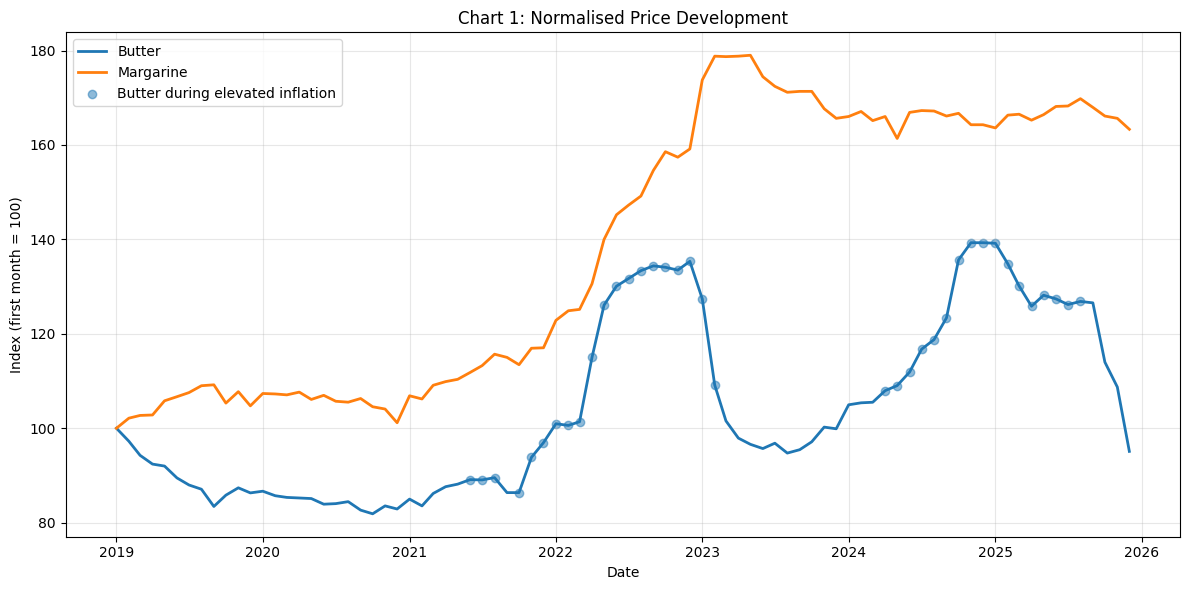

In [34]:
plot_line_chart(analysis_df)


## 10. Chart 2 – Bar chart


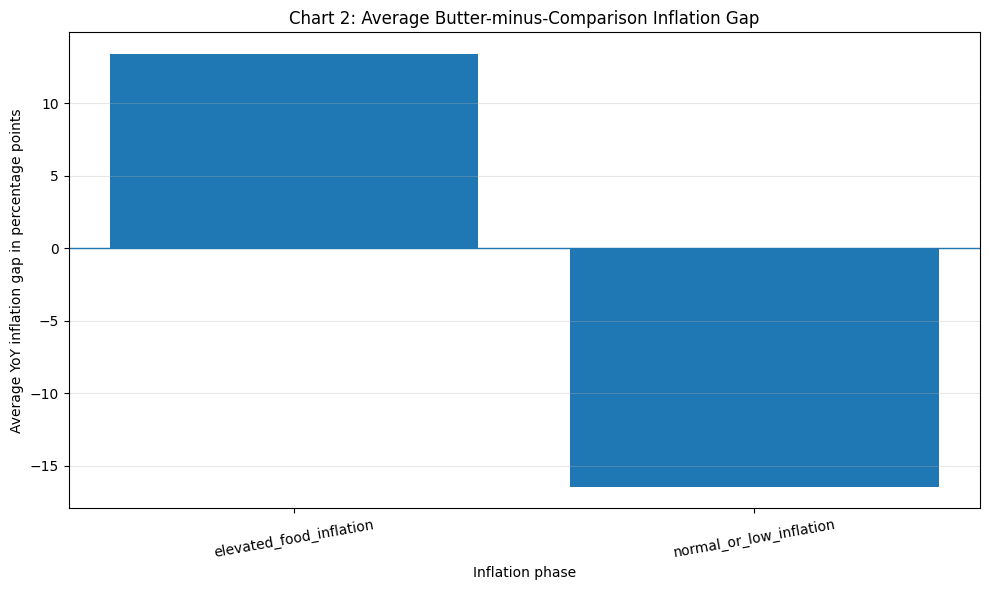

In [35]:
plot_bar_chart(summary_df)


## 11. Chart 3 – Boxplot


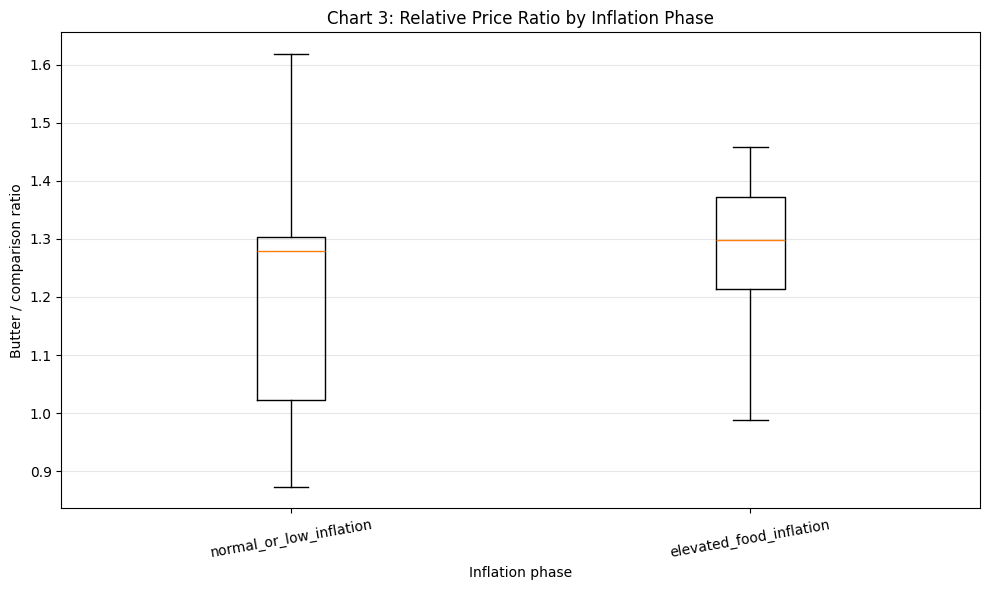

In [36]:
plot_boxplot(analysis_df)


## 12. Chart 4 – Scatter plot


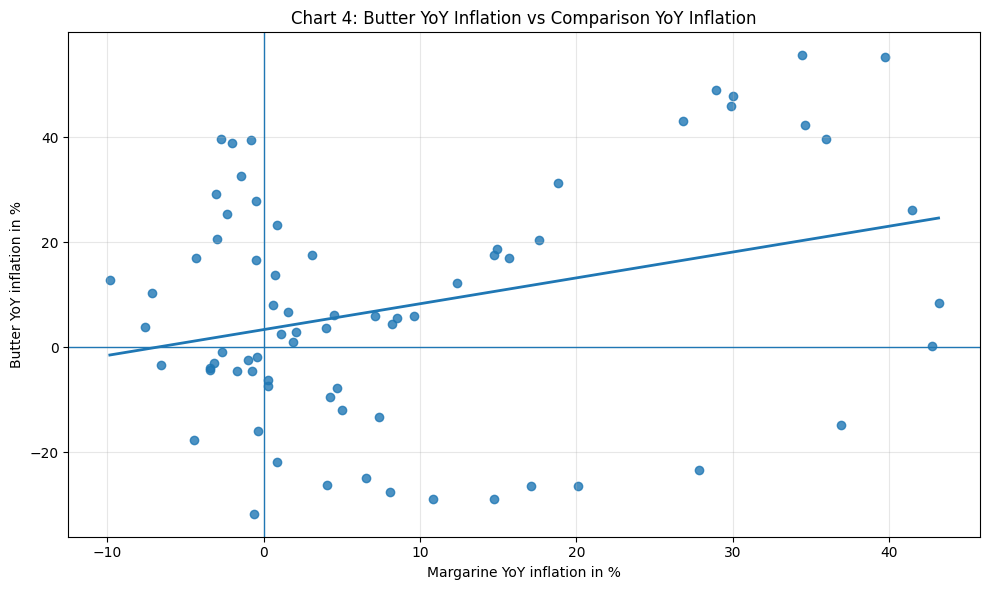

In [37]:
plot_scatter_chart(analysis_df)


## 13. Chart 5 – Heatmap


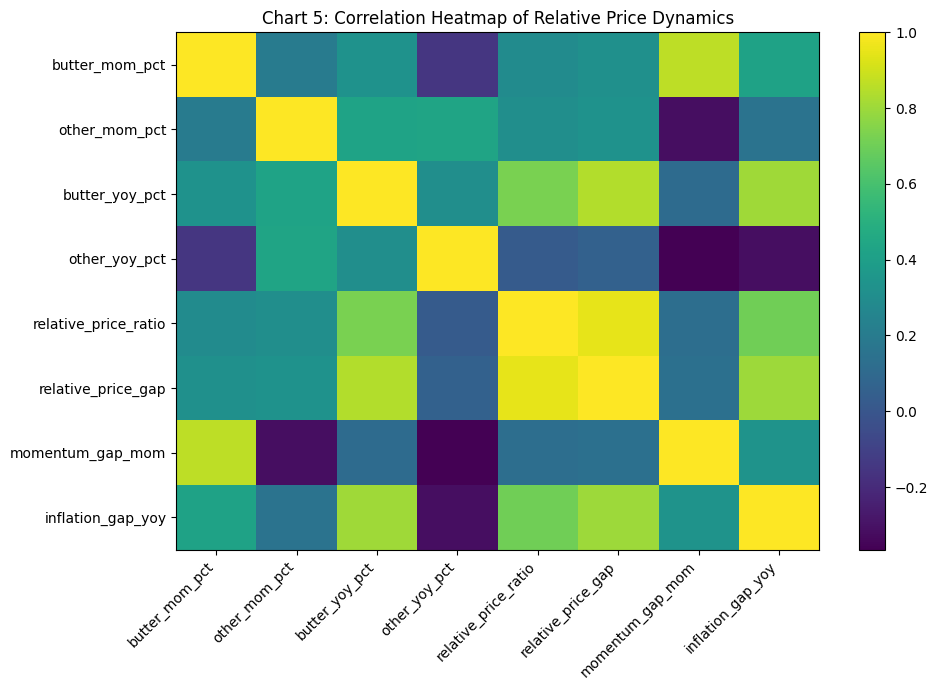

In [38]:
plot_heatmap(analysis_df)


## 14. Optional conclusion text for your presentation

This final cell gives you a short conclusion you can say out loud in the meeting.


In [39]:
print("Suggested presentation conclusion:")
print(
    "We cleaned and merged the butter series with a margarine comparison series, "
    "or a temporary fallback proxy if margarine was not yet available. "
    "Then we constructed relative price indicators such as the butter-to-comparison ratio, "
    "relative gaps, and inflation gaps. Finally, we compared these indicators across "
    "normal and elevated food inflation phases and visualised them with multiple chart types."
)

if data_mode == "fallback_proxy_series":
    print(
        "\nNote: The current run uses a fallback dairy proxy instead of a true margarine series. "
        "For the final research result, the margarine file should be added."
    )


Suggested presentation conclusion:
We cleaned and merged the butter series with a margarine comparison series, or a temporary fallback proxy if margarine was not yet available. Then we constructed relative price indicators such as the butter-to-comparison ratio, relative gaps, and inflation gaps. Finally, we compared these indicators across normal and elevated food inflation phases and visualised them with multiple chart types.


In [40]:
import sqlite3
import os

db_path = 'data/inflation_data.db'

# Verbindung zur Datenbank
conn = sqlite3.connect(db_path)

# Hier benutzen wir 'analysis_df', weil deine Tabelle im Notebook so heißt
analysis_df.to_sql('table_rq2', conn, if_exists='replace', index=False)

conn.close()
print("✅ FERTIG: Frage 2 wurde als 'table_rq2' hinzugefügt.")

✅ FERTIG: Frage 2 wurde als 'table_rq2' hinzugefügt.
